In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import sys
import os
# Add project root to Python path
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root added:")
print(project_root)

Project root added:
/Users/banasreesarkarmou/Desktop/project rough/ml-quant-risk-engine-


In [6]:
from src.risk.historical_var import (
    var_breach_analysis,
    get_breach_statistics
)

# Plot settings
plt.style.use('default')

print("Imports successful")

Imports successful


In [7]:
# Load returns
returns = pd.read_csv(
    '../data/processed/portfolio_returns.csv',
    index_col=0,
    parse_dates=True
)

# Load VaR estimates
var_df = pd.read_csv(
    '../data/processed/var_estimates.csv',
    index_col=0,
    parse_dates=True
)

# Display basic info
print("Returns Shape:", returns.shape)
print("VaR Shape:", var_df.shape)

print("\nReturns Columns:")
print(returns.columns.tolist())

print("\nVaR Columns:")
print(var_df.columns.tolist())

# Preview data
display(returns.head())
display(var_df.head())

Returns Shape: (2859, 5)
VaR Shape: (2859, 10)

Returns Columns:
['SPY', 'QQQ', 'AAPL', 'MSFT', 'GLD']

VaR Columns:
['SPY_95%', 'QQQ_95%', 'AAPL_95%', 'MSFT_95%', 'GLD_95%', 'SPY_99%', 'QQQ_99%', 'AAPL_99%', 'MSFT_99%', 'GLD_99%']


,SPY,QQQ,AAPL,MSFT,GLD
Date,,,,,
2015-01-05,-0.018224,-0.014777,-0.028576,-0.009239,0.014965
2015-01-06,-0.009464,-0.013499,0.000094,-0.014786,0.011334
2015-01-07,0.012384,0.012809,0.013925,0.012625,-0.005909
2015-01-08,0.017589,0.018959,0.037702,0.028994,-0.004217
2015-01-09,-0.008046,-0.006605,0.001072,-0.008441,0.011321


,SPY_95%,QQQ_95%,AAPL_95%,MSFT_95%,GLD_95%,SPY_99%,QQQ_99%,AAPL_99%,MSFT_99%,GLD_99%
Date,,,,,,,,,,
2015-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Choose ticker for analysis
ticker = 'SPY'

# Get returns series
ticker_returns = returns[ticker]

# Get 95% VaR series
ticker_var = var_df[f'{ticker}_95%']

print(f"Analyzing: {ticker}")
print(f"Latest 95% VaR: {ticker_var.iloc[-1]:.4f}")

Analyzing: SPY
Latest 95% VaR: 0.0132


In [9]:
breach_df = var_breach_analysis(
    ticker_returns,
    ticker_var,
    confidence_level=0.95
)

stats = get_breach_statistics(
    breach_df,
    confidence_level=0.95
)

print("=" * 60)
print("BREACH STATISTICS")
print("=" * 60)

print(f"Total Days: {stats['total_days']}")
print(f"Breach Count: {stats['breach_count']}")
print(f"Actual Breach Rate: {stats['breach_rate']:.2%}")
print(f"Expected Breach Rate: {stats['expected_breach_rate']:.2%}")
print(f"Difference: {stats['breach_rate_diff']:.2%}")

print("\nLargest Excess Loss:")
print(f"{stats['max_excess_loss']:.4f}")

print("\nWorst Breach Date:")
print(stats['worst_breach_date'])

BREACH STATISTICS
Total Days: 2859
Breach Count: 123
Actual Breach Rate: 4.30%
Expected Breach Rate: 5.00%
Difference: -0.70%

Largest Excess Loss:
0.0904

Worst Breach Date:
2020-03-16 00:00:00


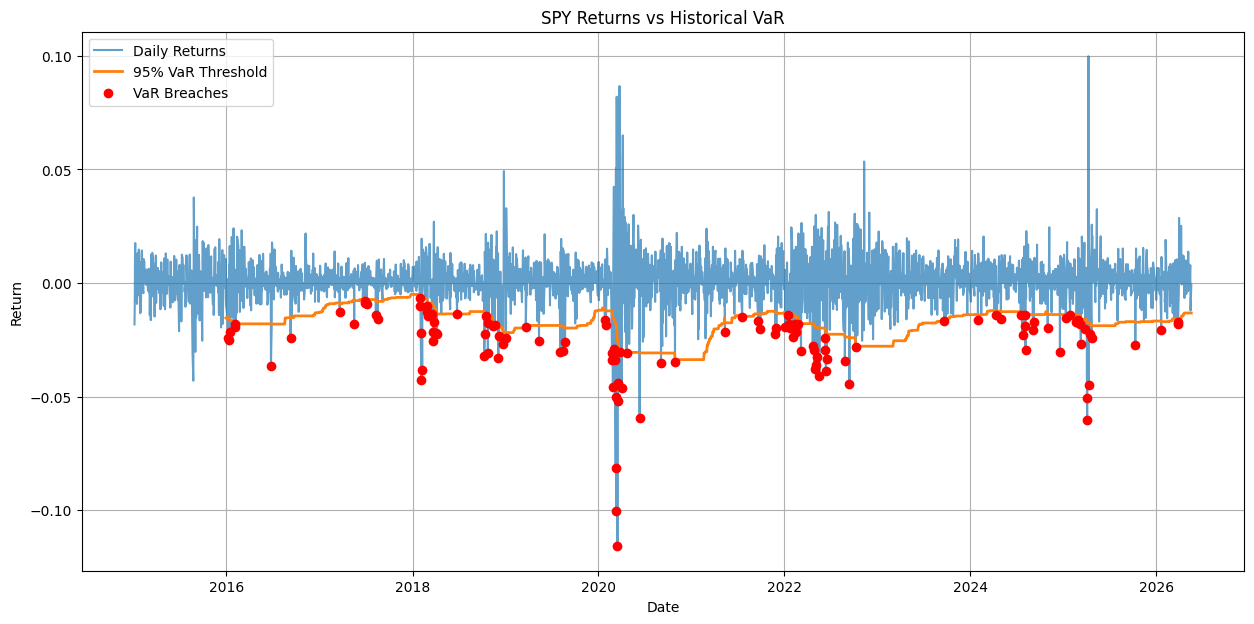

In [10]:
plt.figure(figsize=(15, 7))

# Plot returns
plt.plot(
    breach_df.index,
    breach_df['return'],
    label='Daily Returns',
    alpha=0.7
)

# Plot negative VaR threshold
plt.plot(
    breach_df.index,
    -breach_df['var'],
    label='95% VaR Threshold',
    linewidth=2
)

# Highlight breaches
breaches = breach_df[breach_df['breach']]

plt.scatter(
    breaches.index,
    breaches['return'],
    color='red',
    label='VaR Breaches',
    zorder=5
)

plt.title(f'{ticker} Returns vs Historical VaR')
plt.xlabel('Date')
plt.ylabel('Return')

plt.legend()
plt.grid(True)

plt.show()

In [11]:
breach_rate = breach_df['breach'].mean()

print(f"Observed Breach Rate: {breach_rate:.2%}")
print("Expected Breach Rate: 5.00%")

if abs(breach_rate - 0.05) < 0.02:
    print("✓ VaR model behaving reasonably")
else:
    print("⚠ VaR breach rate differs significantly from expectation")

Observed Breach Rate: 4.30%
Expected Breach Rate: 5.00%
✓ VaR model behaving reasonably


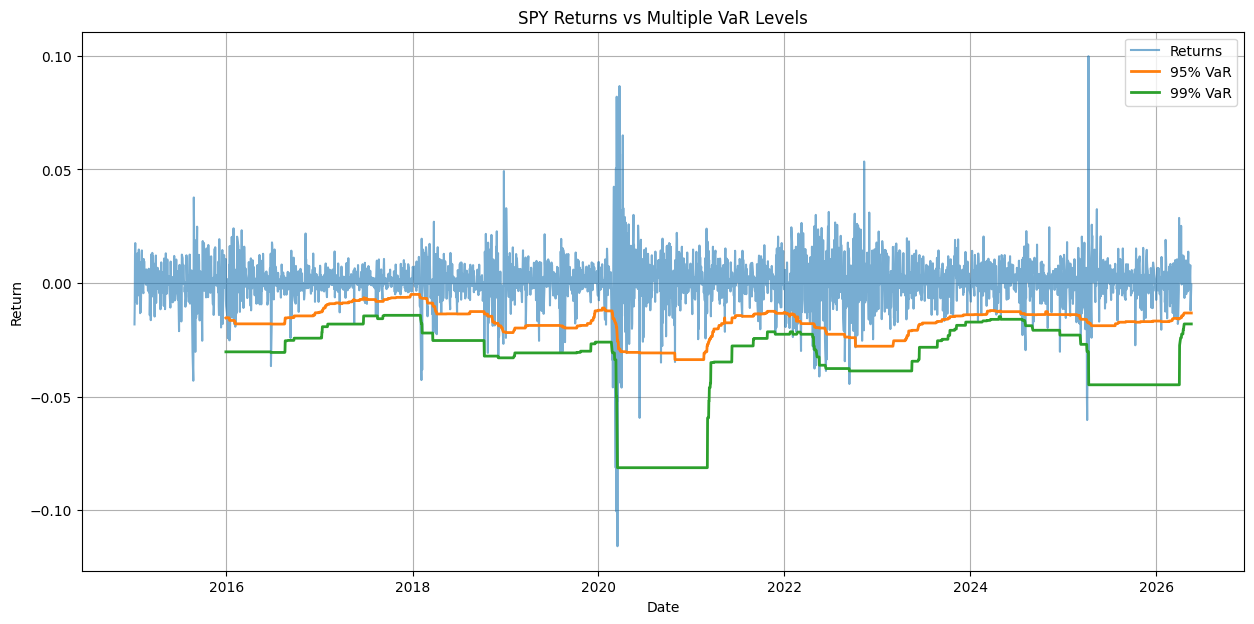

In [12]:
ticker_var_95 = var_df[f'{ticker}_95%']
ticker_var_99 = var_df[f'{ticker}_99%']

plt.figure(figsize=(15, 7))

plt.plot(
    ticker_returns.index,
    ticker_returns,
    label='Returns',
    alpha=0.6
)

plt.plot(
    ticker_var_95.index,
    -ticker_var_95,
    label='95% VaR',
    linewidth=2
)

plt.plot(
    ticker_var_99.index,
    -ticker_var_99,
    label='99% VaR',
    linewidth=2
)

plt.title(f'{ticker} Returns vs Multiple VaR Levels')
plt.xlabel('Date')
plt.ylabel('Return')

plt.legend()
plt.grid(True)

plt.show()

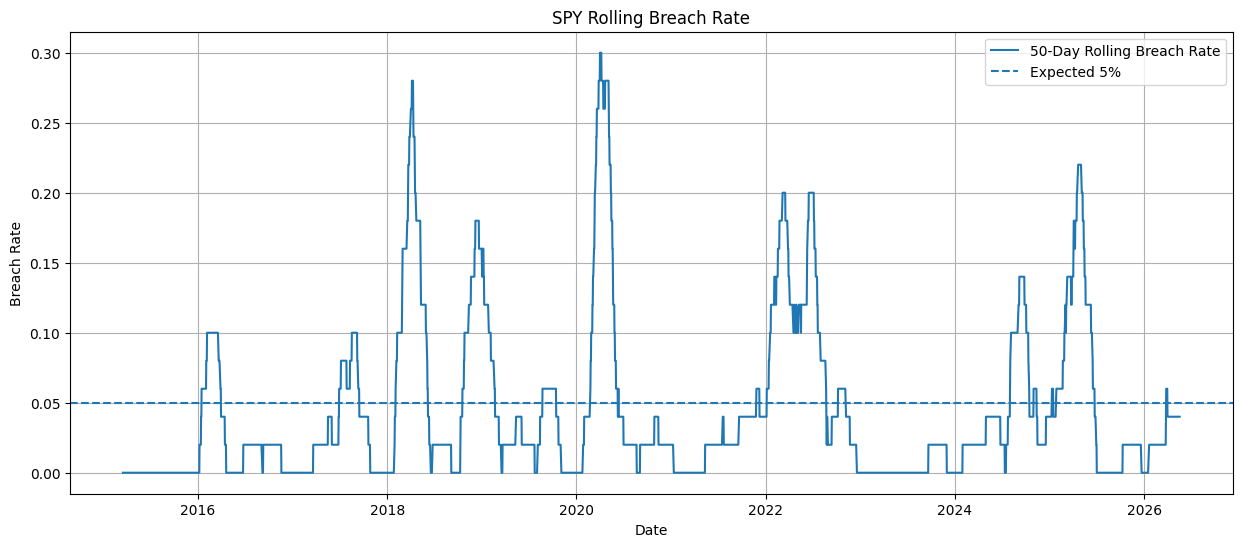

In [13]:
rolling_breach_rate = (
    breach_df['breach']
    .rolling(window=50)
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    rolling_breach_rate.index,
    rolling_breach_rate,
    label='50-Day Rolling Breach Rate'
)

plt.axhline(
    0.05,
    linestyle='--',
    label='Expected 5%'
)

plt.title(f'{ticker} Rolling Breach Rate')
plt.xlabel('Date')
plt.ylabel('Breach Rate')

plt.legend()
plt.grid(True)

plt.show()

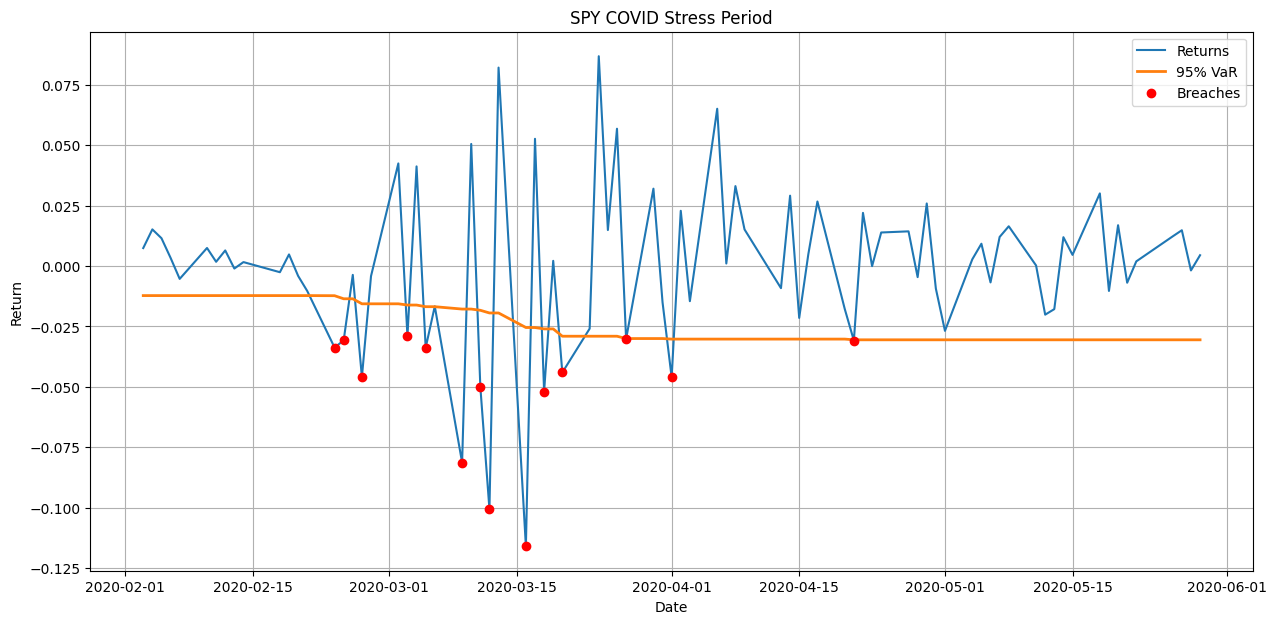

COVID PERIOD ANALYSIS
Breach Count: 14
Breach Rate: 17.07%

Interpretation:
Historical VaR struggled during rapid regime shifts.
Volatility increased faster than rolling window adaptation.


In [14]:
covid_period = breach_df.loc['2020-02-01':'2020-05-31']

plt.figure(figsize=(15, 7))

plt.plot(
    covid_period.index,
    covid_period['return'],
    label='Returns'
)

plt.plot(
    covid_period.index,
    -covid_period['var'],
    label='95% VaR',
    linewidth=2
)

covid_breaches = covid_period[covid_period['breach']]

plt.scatter(
    covid_breaches.index,
    covid_breaches['return'],
    color='red',
    label='Breaches',
    zorder=5
)

plt.title(f'{ticker} COVID Stress Period')
plt.xlabel('Date')
plt.ylabel('Return')

plt.legend()
plt.grid(True)

plt.show()

print("=" * 60)
print("COVID PERIOD ANALYSIS")
print("=" * 60)

print(f"Breach Count: {covid_period['breach'].sum()}")
print(f"Breach Rate: {covid_period['breach'].mean():.2%}")

print("\nInterpretation:")
print("Historical VaR struggled during rapid regime shifts.")
print("Volatility increased faster than rolling window adaptation.")

In [15]:
latest_vars = {}

for col in var_df.columns:
    if '95%' in col:
        latest_vars[col] = var_df[col].iloc[-1]

ranking = (
    pd.Series(latest_vars)
    .sort_values(ascending=False)
)

ranking.index = [
    idx.replace('_95%', '')
    for idx in ranking.index
]

print("=" * 60)
print("RISK RANKING (95% VaR)")
print("=" * 60)

display(ranking)

RISK RANKING (95% VaR)


GLD     0.028234
MSFT    0.025360
AAPL    0.019932
QQQ     0.018655
SPY     0.013194
dtype: float64

Figure saved to docs/historical_var_plot.png


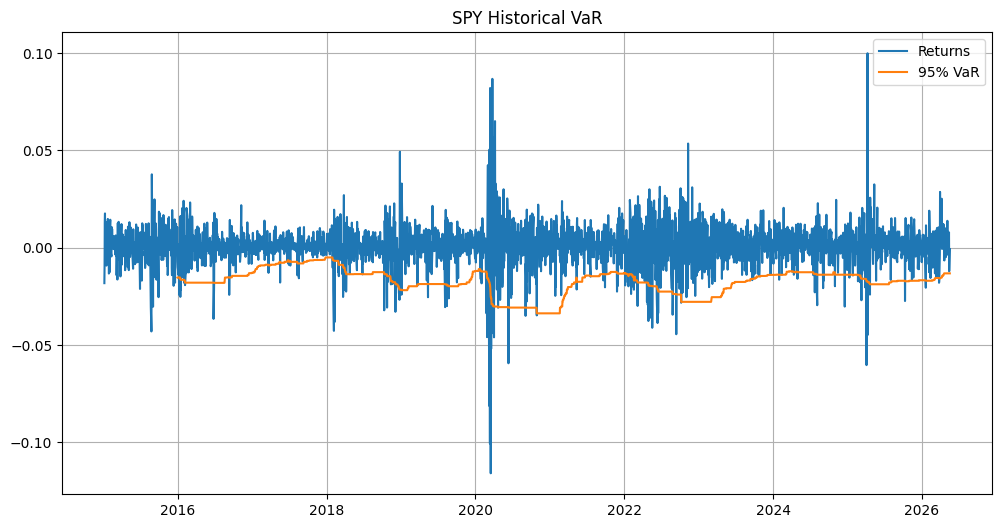

In [16]:
# Save current figure example
plt.figure(figsize=(12, 6))

plt.plot(
    breach_df.index,
    breach_df['return'],
    label='Returns'
)

plt.plot(
    breach_df.index,
    -breach_df['var'],
    label='95% VaR'
)

plt.legend()
plt.grid(True)

plt.title(f'{ticker} Historical VaR')

plt.savefig(
    '../docs/historical_var_plot.png',
    dpi=300,
    bbox_inches='tight'
)

print("Figure saved to docs/historical_var_plot.png")

1. Historical VaR is non-parametric:
   - No normality assumption
   - Uses empirical return distribution

2. Breaches are expected:
   - 95% VaR should fail ~5% of the time

3. Breaches cluster during crises:
   - COVID period showed elevated breach frequency

4. Rolling windows lag regime shifts:
   - VaR adapts slowly to sudden volatility spikes

5. Higher confidence = larger VaR:
   - 99% VaR captures deeper tail losses

6. Diversification matters:
   - Portfolio VaR lower than sum of individual risks